In [8]:
from utils import extract_parcel_mask
from nilearn import datasets, plotting
import logging
from nilearn.plotting import plot_roi
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
from utils import extract_parcel_mask
from nimare.extract import fetch_neurosynth
from nimare.decode import discrete
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from nimare.extract import fetch_neurosynth

plt.rcParams["font.family"] = "Helvetica"

In [10]:
logging.getLogger("nimare.utils").setLevel(logging.ERROR)

In [11]:
from functools import lru_cache


@lru_cache(maxsize=None)
def get_studyset(version, source, vocab, feature_type, target):
    return fetch_neurosynth(
        version=version,
        source=source,
        vocab=vocab,
        type=feature_type,
        return_type="studyset",
        target=target,
    )[0]

In [12]:
def decode_function(
    parcel_num: int,
    *,
    parcellation_file: str | Path,
    version: str = "7",
    source: str = "abstract",
    vocab: str = "terms",
    feature_type: str = "tfidf",
    target: str = "mni152_2mm",
) -> pd.DataFrame:
    """
    Decode a parcel using a NiMARE ROI association decoder.

    Parameters
    ----------
    parcel_num
        Integer label identifying the parcel in the parcellation image.
    parcellation_file
        Path to the labeled parcellation NIfTI image.
    version
        Neurosynth dataset version.
    source
        Text source used to generate annotations, such as ``"abstract"``.
    vocab
        Annotation vocabulary, such as ``"terms"`` or ``"LDA100"``.
    feature_type
        Annotation value type, such as ``"tfidf"`` or ``"weight"``.
    target
        Target image space and resolution.

    Returns
    -------
    pandas.DataFrame
        Decoding results, sorted by correlation when an ``"r"`` column is
        present.

    Raises
    ------
    FileNotFoundError
        If the parcellation file does not exist.
    ValueError
        If the parcel is absent or no matching annotation group is found.
    """
    _, mask_img = extract_parcel_mask(parcellation_file, parcel_num)

    studyset = get_studyset(
        version=version,
        source=source,
        vocab=vocab,
        feature_type=feature_type,
        target=target,
    )

    feature_columns = [
        column
        for column in studyset.annotations_df.columns
        if "__" in column
    ]

    feature_groups = sorted({
        column.split("__", 1)[0]
        for column in feature_columns
    })

    decoder = discrete.ROIAssociationDecoder(
        mask_img,
        feature_group=feature_groups[0],
    )

    decoder.fit(studyset)

    results = decoder.transform()

    return results

In [5]:
import importlib
import utils
parc200 = load_parcellation("neurosynth200")
_, img = extract_parcel_mask(parc200, 40)
img.shape

/Users/amisha/Documents/neurolabel/src/data/parcellations/Neurosynth_Parcellation_k200.nii.gz


(91, 109, 91)

In [13]:
def plot_decoder(decoded_df, top_n=10, bar_color="#F4A300"):
    top = decoded_df.sort_values("r", ascending=False).head(top_n).copy()

    top.index = top.index.str.replace(
        r"^(?:LDA\d+_abstract_weight__\d+_|terms_abstract_tfidf__)",
        "",
        regex=True,
    )

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.barh(top.index, top["r"], color=bar_color)
    ax.invert_yaxis()

    ax.set_xlabel("Correlation (r)", fontsize=13)
    ax.set_ylabel("")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=12)
    fig.tight_layout()

In [14]:
decoded_df = decode_function(
    parcel_num=11,
    parcellation_file=(
        "../parcellations/neurosynth/"
        "Neurosynth_Parcellation_k100.nii.gz"
    ),
    version="7",
    source="abstract",
    vocab="LDA200",
    feature_type="weight")

INFO:nimare.extract.utils:Dataset found in /Users/amisha/.nimare/neurosynth

INFO:nimare.extract.extract:Searching for any feature files matching the following criteria: [('source-abstract', 'vocab-LDA200', 'type-weight', 'data-neurosynth', 'version-7')]


File exists and overwrite is False. Skipping.
File exists and overwrite is False. Skipping.
File exists and overwrite is False. Skipping.
File exists and overwrite is False. Skipping.
File exists and overwrite is False. Skipping.
File exists and overwrite is False. Skipping.


In [4]:
from importlib.resources import as_file, files

PARCELLATIONS = {
    "neurosynth50": "Neurosynth_Parcellation_k50.nii.gz",
    "neurosynth100": "Neurosynth_Parcellation_k100.nii.gz",
    "neurosynth200": "Neurosynth_Parcellation_k200.nii.gz",
}


def load_neurosynth(name: str) -> nib.Nifti1Image:
    """Load a bundled parcellation."""
    try:
        filename = PARCELLATIONS[name.lower()]
    except KeyError as exc:
        available = ", ".join(sorted(PARCELLATIONS))
        raise ValueError(
            f"Unknown parcellation '{name}'. "
            f"Available parcellations: {available}."
        ) from exc

    resource = files("data.parcellations").joinpath(filename)
    print(resource)

    with as_file(resource) as path:
        image = nib.load(path)

        return nib.Nifti1Image(
            np.asanyarray(image.dataobj),
            image.affine,
            image.header.copy(),
        )

In [143]:
from nilearn import datasets


def load_dataset(name: str, **kwargs):
    """Load a supported atlas from Nilearn."""

    fetchers = {
        "aal": datasets.fetch_atlas_aal,
        "schaefer": datasets.fetch_atlas_schaefer_2018,
        "harvard_oxford": datasets.fetch_atlas_harvard_oxford,
        "juelich": datasets.fetch_atlas_juelich,
        "msdl": datasets.fetch_atlas_msdl,
        "difumo": datasets.fetch_atlas_difumo,
    }

    try:
        fetch = fetchers[name.lower()]
    except KeyError:
        raise ValueError(
            f"Unsupported dataset '{name}'. "
            f"Available datasets: {', '.join(fetchers)}."
        )

    return fetch(verbose=0, **kwargs)

In [15]:
import plotly.express as px

# Create a bar plot using Plotly
fig = px.bar(
    decoded_df.head(10).reset_index(),
    x='r',
    y='index',
    labels={'r': 'Correlation (r)', 'index': 'Features'},
    orientation='h',
    title='Top 10 Features by Correlation'
)

fig.show()


# plot_decoder(decoded_df, top_n=10)

ValueError: Value of 'y' is not the name of a column in 'data_frame'. Expected one of ['feature', 'r'] but received: index
 To use the index, pass it in directly as `df.index`.

In [44]:
from nilearn import datasets, image

parcellation_file = "../parcellations/neurosynth/Neurosynth_Parcellation_k100.nii.gz"

_, mask_img = extract_parcel_mask(parcellation_file, 3)

atlas = datasets.fetch_atlas_harvard_oxford(
    "cort-maxprob-thr25-2mm"
)

atlas_img = image.resample_to_img(
    atlas.maps,
    mask_img,
    interpolation="nearest",
)

parcel = mask_img.get_fdata().astype(bool)
atlas_data = atlas_img.get_fdata().astype(int)

[fetch_atlas_harvard_oxford] Dataset found in /Users/amisha/nilearn_data/fsl


In [60]:
results = []

for region_id, region_name in enumerate(atlas.labels[1:], start=1):
    region_mask = atlas_data == region_id
    intersection = np.logical_and(parcel, region_mask).sum()

    results.append({
        "region": region_name,
        "intersection_voxels": intersection,
        "parcel_overlap": intersection / parcel.sum()
    })

overlap_df = (
    pd.DataFrame(results)
    .sort_values("parcel_overlap", ascending=False)
    .reset_index(drop=True)
)

overlap_df.head(10)

,region,intersection_voxels,parcel_overlap
0,Frontal Orbital Cortex,794,0.387506
1,Frontal Pole,792,0.386530
2,"Inferior Frontal Gyrus, pars triangularis",134,0.065398
3,Temporal Pole,99,0.048316
4,"Inferior Frontal Gyrus, pars opercularis",2,0.000976
5,"Temporal Fusiform Cortex, posterior division",0,0.000000
6,"Cingulate Gyrus, anterior division",0,0.000000
7,"Cingulate Gyrus, posterior division",0,0.000000
8,Precuneous Cortex,0,0.000000
9,Cuneal Cortex,0,0.000000


In [171]:
total = 0
parcel_dict = {}

min_voxels = 20
voxel_volume_mm3 = abs(np.linalg.det(mask_img.affine[:3, :3]))
min_size_mm3 = min_voxels * voxel_volume_mm3

for num_parcel in range(1, 101):
    mask_data, mask_img = extract_parcel_mask(
        "../parcellations/neurosynth/Neurosynth_Parcellation_k100.nii.gz", num_parcel)
    split_img = connected_label_regions(mask_img, min_size=min_size_mm3)
    total += np.unique(split_img.get_fdata())[1:].shape[0]
    parcel_dict[num_parcel] = np.unique(split_img.get_fdata())[1:]

In [170]:
min_size_mm3

np.float64(399.9999999999999)

In [172]:
total

184

In [173]:
parcel_dict

{1: array([1., 2.]),
 2: array([1.]),
 3: array([1., 2.]),
 4: array([1.]),
 5: array([1., 2.]),
 6: array([1.]),
 7: array([1.]),
 8: array([1., 2.]),
 9: array([1.]),
 10: array([1., 2.]),
 11: array([1., 2.]),
 12: array([1., 2.]),
 13: array([1., 2.]),
 14: array([1.]),
 15: array([1., 2.]),
 16: array([1.]),
 17: array([1., 2.]),
 18: array([1., 2.]),
 19: array([1., 2.]),
 20: array([1., 2.]),
 21: array([1., 2.]),
 22: array([1., 2.]),
 23: array([1.]),
 24: array([1., 2.]),
 25: array([1.]),
 26: array([1.]),
 27: array([1., 2.]),
 28: array([1., 2.]),
 29: array([1., 2.]),
 30: array([1.]),
 31: array([1., 2.]),
 32: array([1., 2.]),
 33: array([1., 2.]),
 34: array([1., 2.]),
 35: array([1., 2.]),
 36: array([1.]),
 37: array([1.]),
 38: array([1., 2.]),
 39: array([1.]),
 40: array([1.]),
 41: array([1.]),
 42: array([1., 2.]),
 43: array([1.]),
 44: array([1., 2., 3.]),
 45: array([1., 2., 3.]),
 46: array([1.]),
 47: array([1., 2.]),
 48: array([1., 2.]),
 49: array([1., 2

In [167]:
data = split_img.get_fdata()
labels, counts = np.unique(data, return_counts=True)

for label, count in zip(labels, counts):
    print(f"Label {int(label)}: {count} voxels")

Label 0: 900982 voxels
Label 1: 757 voxels
Label 2: 58 voxels
Label 3: 832 voxels


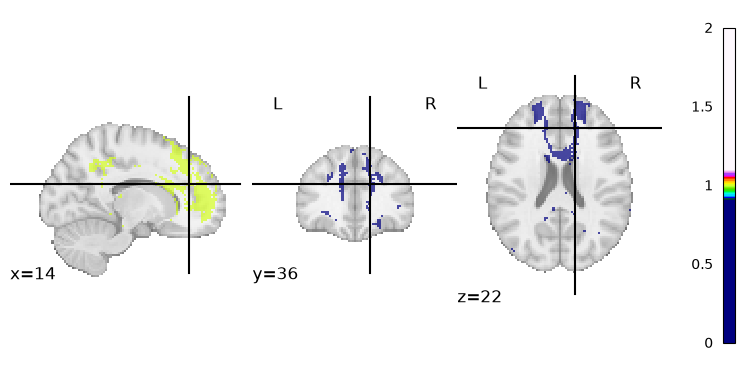

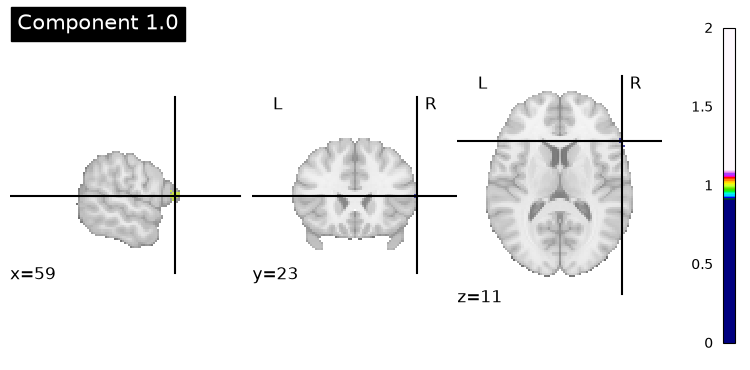

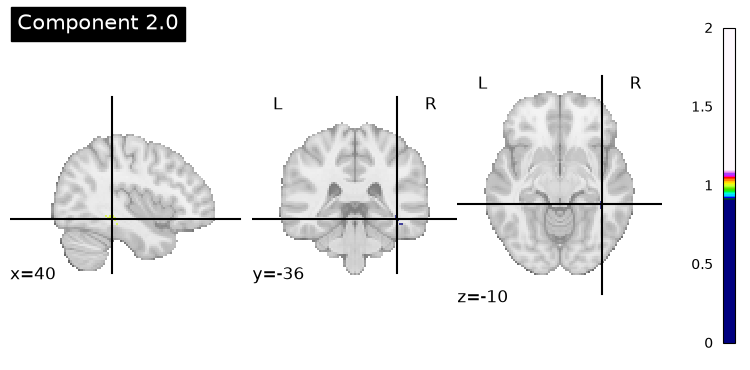

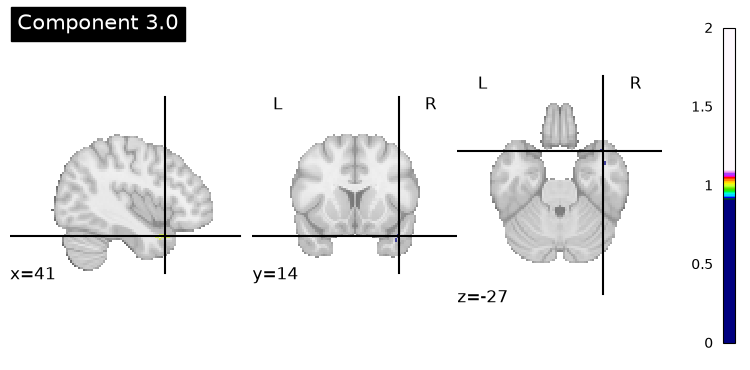

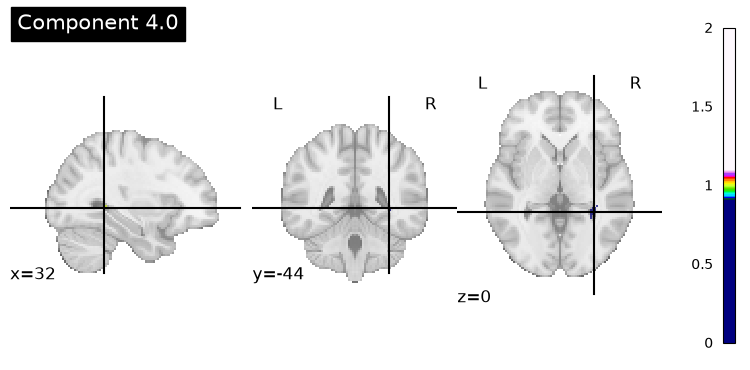

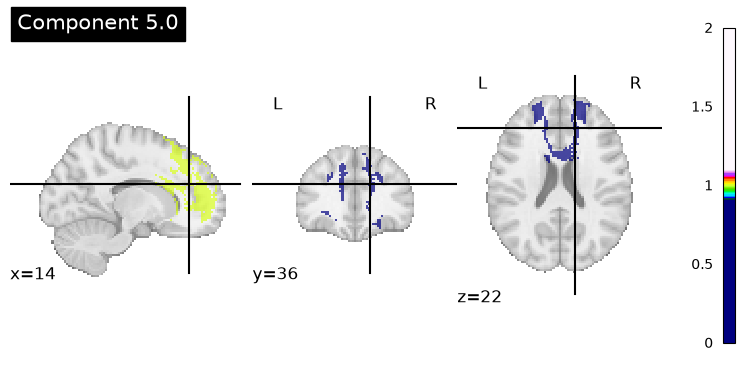

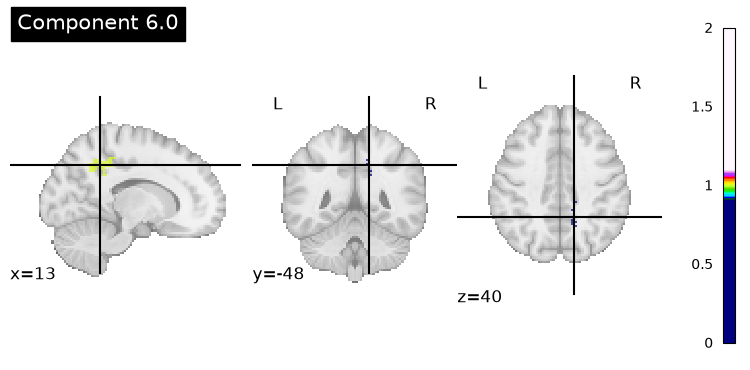

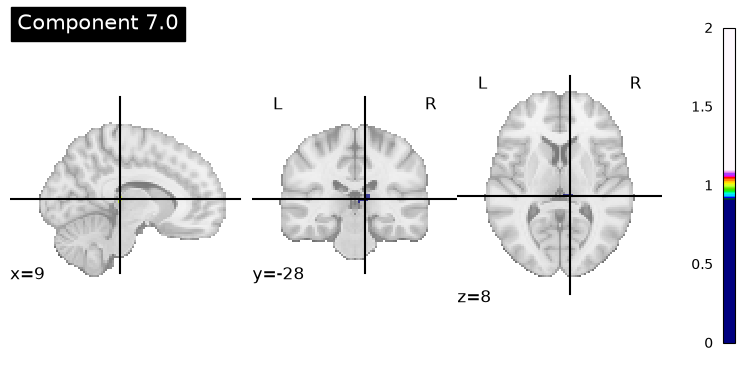

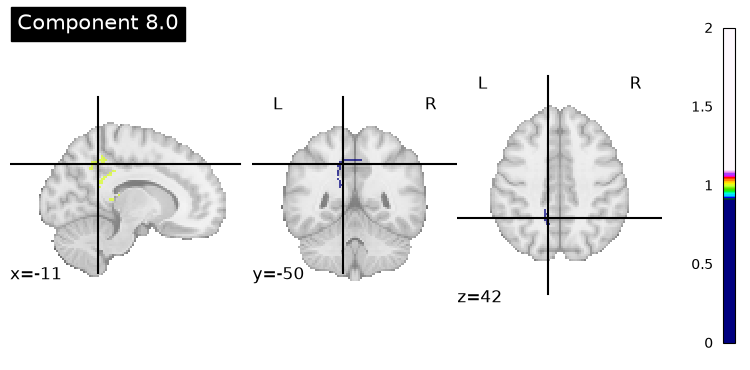

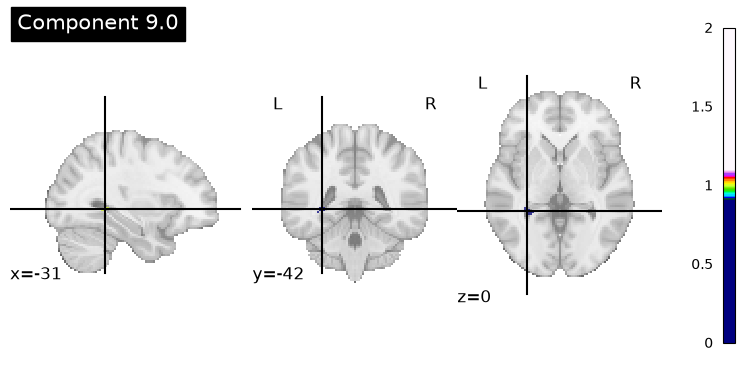

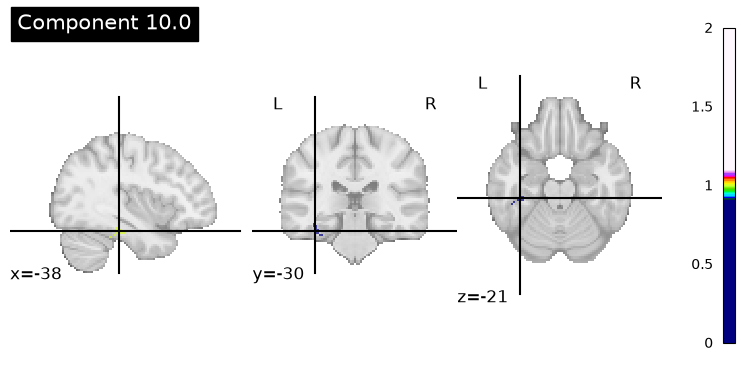

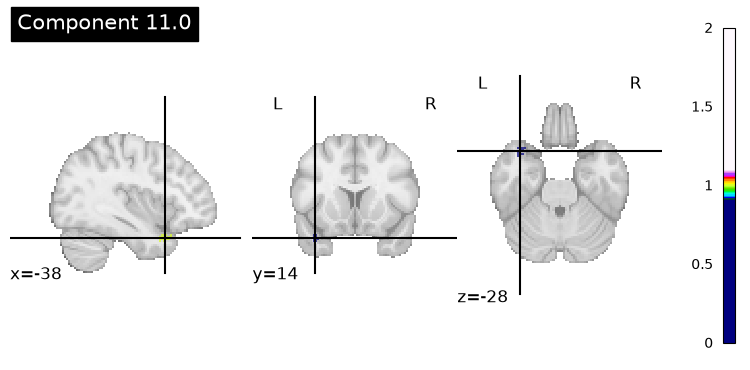

In [175]:
from nilearn.image import math_img
from nilearn.plotting import plot_roi, show

min_voxels = 20
voxel_volume_mm3 = abs(np.linalg.det(mask_img.affine[:3, :3]))
min_size_mm3 = min_voxels * voxel_volume_mm3

mask_data, mask_img = extract_parcel_mask(
    "../parcellations/neurosynth/Neurosynth_Parcellation_k100.nii.gz", 95)

split_img = connected_label_regions(mask_img, min_size=min_size_mm3)
plot_roi(mask_img)

for label in np.unique(split_img.get_fdata())[1:]:
    img = math_img(f"img == {label}", img=split_img)
    plot_roi(img, title=f"Component {label}")

show()

In [ ]:
coords = find_parcellation_cut_coords(split_img)

In [74]:
from nimare.nimads import Studyset
from nimare.utils import get_resource_path
import os

In [40]:
studyset = Studyset(
    os.path.join(get_resource_path(), "neurosynth_laird_studyset.json"),
    target="mni152_2mm",
)
studyset.annotations_df.head(5)

,id,study_id,contrast_id,Neurosynth_TFIDF__001,Neurosynth_TFIDF__01,Neurosynth_TFIDF__05,Neurosynth_TFIDF__10,Neurosynth_TFIDF__100,Neurosynth_TFIDF__11,Neurosynth_TFIDF__12,...,Neurosynth_TFIDF__yield,Neurosynth_TFIDF__yielded,Neurosynth_TFIDF__young,Neurosynth_TFIDF__young adults,Neurosynth_TFIDF__young healthy,Neurosynth_TFIDF__young older,Neurosynth_TFIDF__younger,Neurosynth_TFIDF__younger adults,Neurosynth_TFIDF__youth,Neurosynth_TFIDF__zone
0,17029760-1,17029760,1,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,18760263-1,18760263,1,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,19162389-1,19162389,1,0.0,0.0,0.0,0.0,0.0,0.176321,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,19603407-1,19603407,1,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,20197097-1,20197097,1,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Parcel 3 in 100

In [116]:
from nimare.extract import fetch_neurosynth

studyset = fetch_neurosynth(
    version="7",
    source="abstract",
    vocab="LDA100",
    type="weight",
    return_type="studyset",
    target="mni152_2mm",
)[0]

feature_columns = [
    column
    for column in studyset.annotations_df.columns
    if "__" in column
]

feature_groups = sorted({
    column.split("__", 1)[0]
    for column in feature_columns
})

decoder = discrete.ROIAssociationDecoder(
    mask_img,
    feature_group=feature_groups[0],  # use exact value printed above
)

decoder.fit(studyset)

decoded_df = decoder.transform()
decoded_df = decoded_df.sort_values("r", ascending=False)

print(decoded_df.head(20))

INFO:nimare.extract.utils:Dataset found in /Users/amisha/.nimare/neurosynth

INFO:nimare.extract.extract:Searching for any feature files matching the following criteria: [('source-abstract', 'vocab-LDA100', 'type-weight', 'data-neurosynth', 'version-7')]


File exists and overwrite is False. Skipping.
File exists and overwrite is False. Skipping.
File exists and overwrite is False. Skipping.
File exists and overwrite is False. Skipping.
File exists and overwrite is False. Skipping.
File exists and overwrite is False. Skipping.


                                                           r
feature                                                     
LDA100_abstract_weight__30_emotional_negative_p...  0.086642
LDA100_abstract_weight__12_language_comprehensi...  0.078899
LDA100_abstract_weight__41_memory_retrieval_epi...  0.070153
LDA100_abstract_weight__61_caudate_ofc_thalamus     0.068332
LDA100_abstract_weight__35_regulation_emotion_r...  0.067634
LDA100_abstract_weight__92_social_empathy_moral     0.065743
LDA100_abstract_weight__80_pictures_images_aver...  0.065553
LDA100_abstract_weight__23_semantic_words_word      0.059277
LDA100_abstract_weight__71_reasoning_mind_mental    0.058524
LDA100_abstract_weight__43_prefrontal_cortex_pfc    0.056640
LDA100_abstract_weight__72_memory_encoding_hipp...  0.049433
LDA100_abstract_weight__83_cortex_anterior_cing...  0.047607
LDA100_abstract_weight__91_amygdala_emotional_f...  0.043087
LDA100_abstract_weight__1_gyrus_frontal_middle      0.040064
LDA100_abstract_weight__

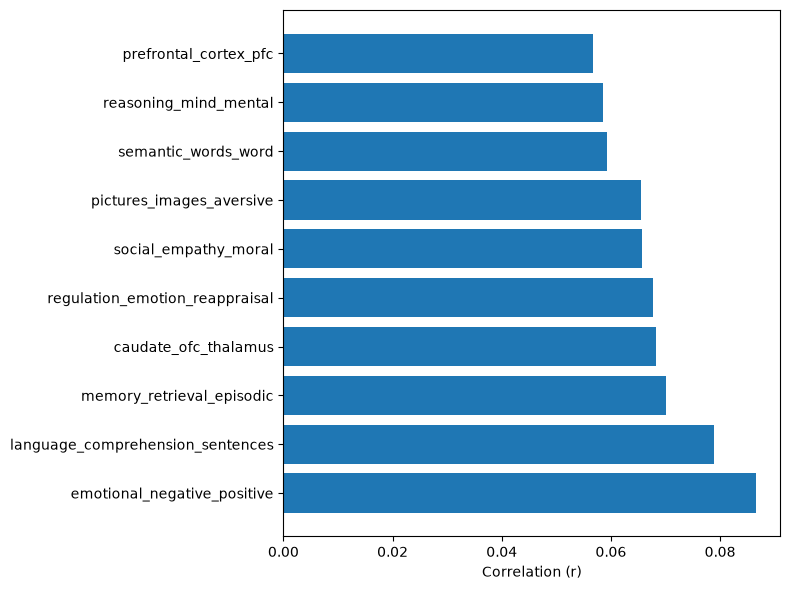

In [123]:
decoded_df.index = decoded_df.index.str.replace(
    r"^LDA\d+_abstract_weight__\d+_",
    "",
    regex=True,
)

plt.figure(figsize=(8, 6))
plt.barh(decoded_df.index[:10], decoded_df["r"][:10])

plt.xlabel("Correlation (r)")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [90]:
decoder = discrete.ROIAssociationDecoder(
    mask_img,
    feature_group="LDA100_abstract_weight",  # use exact value printed above
)

decoder.fit(studyset)

decoded_df = decoder.transform()
decoded_df = decoded_df.sort_values("r", ascending=False)

print(decoded_df.head(20))

                                                           r
feature                                                     
LDA100_abstract_weight__41_memory_retrieval_epi...  0.141385
LDA100_abstract_weight__67_network_state_resting    0.138984
LDA100_abstract_weight__83_cortex_anterior_cing...  0.082289
LDA100_abstract_weight__9_imagery_mental_events     0.074454
LDA100_abstract_weight__71_reasoning_mind_mental    0.050295
LDA100_abstract_weight__76_memory_recognition_i...  0.036768
LDA100_abstract_weight__95_adults_age_older         0.034105
LDA100_abstract_weight__40_ad_disease_mci           0.033003
LDA100_abstract_weight__96_patterns_cortex_common   0.030956
LDA100_abstract_weight__30_emotional_negative_p...  0.030922
LDA100_abstract_weight__19_judgments_judgment_ppc   0.029209
LDA100_abstract_weight__94_network_control_fron...  0.028984
LDA100_abstract_weight__72_memory_encoding_hipp...  0.027468
LDA100_abstract_weight__92_social_empathy_moral     0.023419
LDA100_abstract_weight__